# 02 — Look-Ahead-Safe Underlying Alignment and Exploratory Data Analysis

This notebook converts the raw SPY, SPX and VIX minute database into:

1. a one-minute aligned underlying dataset;
2. a session-level data-quality audit;
3. a daily modelling dataset using information available before 15:00 ET;
4. exploratory tables and dissertation-ready graphical outputs.

## Look-ahead rule

SPY is used as the minute clock. SPX and VIX are matched using the latest observation at or before each SPY timestamp, with a maximum tolerance of two minutes. Future observations are never used.

For a prediction made at 15:00 ET:

- features use bars timestamped strictly before `15:00:00`;
- the last intended feature bar is therefore `14:59:00`;
- the target is the SPX return from the last available price before 15:00 to the last available price before 16:00.

The notebook does not call the Massive API and does not require the API key.

## 1. Environment and database connection

Place this notebook inside the existing `massive_market_database` project. It searches the current folder and its parents for `data/market.duckdb`.

If an import fails, run:

```python
%pip install duckdb pandas pyarrow matplotlib
```

In [3]:
from pathlib import Path
from datetime import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    """Find the nearest folder containing data/market.duckdb."""
    start = start.resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook in the Massive database project folder."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
FIGURE_ROOT = OUTPUT_ROOT / "eda_figures"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Derived data:", DERIVED_ROOT)
print("EDA figures:", FIGURE_ROOT)


def save_figure(fig, filename: str) -> Path:
    """Save a high-resolution PNG and return its path."""
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Database: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\market.duckdb
Derived data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived
EDA figures: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures


## 2. Validate the database and identify ticker names

The corrected views should contain `SPY`, `I:SPX` and `I:VIX`. The fallback aliases `I_SPX` and `I_VIX` are accepted so the notebook can still diagnose an older view definition.

In [4]:
available_relations = con.execute(
    """
    SELECT table_name, table_type
    FROM information_schema.tables
    ORDER BY table_name
    """
).df()

required_relation = "underlying_regular_session"

if required_relation not in set(available_relations["table_name"]):
    raise RuntimeError(
        "The view underlying_regular_session was not found. "
        "Run the corrected view-registration cell in the first notebook."
    )

ticker_coverage = con.execute(
    """
    SELECT
        ticker,
        COUNT(*) AS minute_bars,
        MIN(timestamp_et) AS first_timestamp,
        MAX(timestamp_et) AS last_timestamp,
        COUNT(DISTINCT session_date) AS sessions
    FROM underlying_regular_session
    GROUP BY ticker
    ORDER BY ticker
    """
).df()

display(ticker_coverage)

available_tickers = set(ticker_coverage["ticker"].astype(str))

SPY_TICKER = "SPY"
SPX_TICKER = "I:SPX" if "I:SPX" in available_tickers else "I_SPX"
VIX_TICKER = "I:VIX" if "I:VIX" in available_tickers else "I_VIX"

required_tickers = {SPY_TICKER, SPX_TICKER, VIX_TICKER}
missing_tickers = required_tickers.difference(available_tickers)

if missing_tickers:
    raise RuntimeError(
        f"Missing required tickers: {sorted(missing_tickers)}. "
        f"Available tickers: {sorted(available_tickers)}"
    )

print("Selected ticker mapping:")
print({"SPY": SPY_TICKER, "SPX": SPX_TICKER, "VIX": VIX_TICKER})

,ticker,minute_bars,first_timestamp,last_timestamp,sessions
0,I:SPX,194233,2024-07-18 09:30:00,2026-07-17 15:59:00,501
1,I:VIX,188009,2024-07-18 09:31:00,2026-07-17 15:59:00,515
2,SPY,194495,2024-07-18 09:30:00,2026-07-17 15:59:00,501


Selected ticker mapping:
{'SPY': 'SPY', 'SPX': 'I:SPX', 'VIX': 'I:VIX'}


## 3. Load the regular-session data

SPY supplies the canonical minute clock. Duplicate timestamps are reported and removed before alignment.

In [5]:
spy = con.execute(
    """
    SELECT
        timestamp_utc,
        timestamp_et,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS spy_open,
        high AS spy_high,
        low AS spy_low,
        close AS spy_close,
        volume AS spy_volume,
        vwap AS spy_vwap,
        transactions AS spy_transactions
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [SPY_TICKER],
).df()

spx = con.execute(
    """
    SELECT
        timestamp_utc AS spx_timestamp_utc,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS spx_open,
        high AS spx_high,
        low AS spx_low,
        close AS spx_close
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [SPX_TICKER],
).df()

vix = con.execute(
    """
    SELECT
        timestamp_utc AS vix_timestamp_utc,
        CAST(session_date AS VARCHAR) AS session_date,
        open AS vix_open,
        high AS vix_high,
        low AS vix_low,
        close AS vix_close
    FROM underlying_regular_session
    WHERE ticker = ?
    ORDER BY timestamp_utc
    """,
    [VIX_TICKER],
).df()

spy["timestamp_utc"] = pd.to_datetime(spy["timestamp_utc"], utc=True)
spy["timestamp_et"] = pd.to_datetime(spy["timestamp_et"])

spx["spx_timestamp_utc"] = pd.to_datetime(spx["spx_timestamp_utc"], utc=True)
vix["vix_timestamp_utc"] = pd.to_datetime(vix["vix_timestamp_utc"], utc=True)

duplicate_report = pd.DataFrame(
    {
        "dataset": ["SPY", "SPX", "VIX"],
        "duplicate_timestamps": [
            spy.duplicated(["timestamp_utc"]).sum(),
            spx.duplicated(["spx_timestamp_utc"]).sum(),
            vix.duplicated(["vix_timestamp_utc"]).sum(),
        ],
        "rows_before_deduplication": [len(spy), len(spx), len(vix)],
    }
)

display(duplicate_report)

spy = (
    spy.drop_duplicates(["timestamp_utc"], keep="last")
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

spx = (
    spx.drop_duplicates(["spx_timestamp_utc"], keep="last")
    .sort_values("spx_timestamp_utc")
    .reset_index(drop=True)
)

vix = (
    vix.drop_duplicates(["vix_timestamp_utc"], keep="last")
    .sort_values("vix_timestamp_utc")
    .reset_index(drop=True)
)

print("Rows after deduplication:")
print({"SPY": len(spy), "SPX": len(spx), "VIX": len(vix)})

,dataset,duplicate_timestamps,rows_before_deduplication
0,SPY,0,194495
1,SPX,0,194233
2,VIX,0,188009


Rows after deduplication:
{'SPY': 194495, 'SPX': 194233, 'VIX': 188009}


## 4. Perform backward as-of alignment

A two-minute tolerance prevents stale values from being carried forward indefinitely. Unmatched observations remain missing and are included in the quality audit.

In [6]:
MATCH_TOLERANCE = pd.Timedelta("2 minutes")

aligned = pd.merge_asof(
    left=spy.sort_values("timestamp_utc"),
    right=spx.sort_values("spx_timestamp_utc"),
    left_on="timestamp_utc",
    right_on="spx_timestamp_utc",
    by="session_date",
    direction="backward",
    tolerance=MATCH_TOLERANCE,
)

aligned = pd.merge_asof(
    left=aligned.sort_values("timestamp_utc"),
    right=vix.sort_values("vix_timestamp_utc"),
    left_on="timestamp_utc",
    right_on="vix_timestamp_utc",
    by="session_date",
    direction="backward",
    tolerance=MATCH_TOLERANCE,
)

aligned["spx_staleness_seconds"] = (
    aligned["timestamp_utc"] - aligned["spx_timestamp_utc"]
).dt.total_seconds()

aligned["vix_staleness_seconds"] = (
    aligned["timestamp_utc"] - aligned["vix_timestamp_utc"]
).dt.total_seconds()

aligned["clock_minute"] = (
    aligned["timestamp_et"].dt.hour * 60
    + aligned["timestamp_et"].dt.minute
)

future_spx_matches = (
    aligned["spx_timestamp_utc"].notna()
    & (aligned["spx_timestamp_utc"] > aligned["timestamp_utc"])
).sum()

future_vix_matches = (
    aligned["vix_timestamp_utc"].notna()
    & (aligned["vix_timestamp_utc"] > aligned["timestamp_utc"])
).sum()

alignment_summary = pd.DataFrame(
    {
        "metric": [
            "aligned rows",
            "missing SPX matches",
            "missing VIX matches",
            "future SPX matches",
            "future VIX matches",
            "maximum SPX staleness (seconds)",
            "maximum VIX staleness (seconds)",
        ],
        "value": [
            len(aligned),
            aligned["spx_close"].isna().sum(),
            aligned["vix_close"].isna().sum(),
            future_spx_matches,
            future_vix_matches,
            aligned["spx_staleness_seconds"].max(),
            aligned["vix_staleness_seconds"].max(),
        ],
    }
)

display(alignment_summary)
display(aligned.head())

assert future_spx_matches == 0, "A future SPX observation was matched."
assert future_vix_matches == 0, "A future VIX observation was matched."
assert aligned["spx_staleness_seconds"].dropna().le(120).all()
assert aligned["vix_staleness_seconds"].dropna().le(120).all()

,metric,value
0,aligned rows,"194,495.000000"
1,missing SPX matches,267.000000
2,missing VIX matches,"1,098.000000"
3,future SPX matches,0.000000
4,future VIX matches,0.000000
5,maximum SPX staleness (seconds),120.000000
6,maximum VIX staleness (seconds),120.000000


,timestamp_utc,timestamp_et,session_date,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_vwap,spy_transactions,spx_timestamp_utc,spx_open,spx_high,spx_low,spx_close,vix_timestamp_utc,vix_open,vix_high,vix_low,vix_close,spx_staleness_seconds,vix_staleness_seconds,clock_minute
0,2024-07-18 13:30:00+00:00,2024-07-18 09:30:00,2024-07-18,558.510000,558.640000,558.110000,558.140000,"1,006,486.000000",558.415600,7439,2024-07-18 13:30:00+00:00,"5,608.560000","5,608.560000","5,601.360000","5,601.380000",NaT,NaN,NaN,NaN,NaN,0.000000,NaN,570
1,2024-07-18 13:31:00+00:00,2024-07-18 09:31:00,2024-07-18,558.140000,558.180400,558.010000,558.159900,"158,361.000000",558.093000,1938,2024-07-18 13:31:00+00:00,"5,601.150000","5,601.530000","5,599.260000","5,599.720000",2024-07-18 13:31:00+00:00,14.390000,14.410000,14.390000,14.410000,0.000000,0.000000,571
2,2024-07-18 13:32:00+00:00,2024-07-18 09:32:00,2024-07-18,558.155000,558.260000,558.040000,558.190000,"106,308.000000",558.133400,1217,2024-07-18 13:32:00+00:00,"5,599.520000","5,600.980000","5,598.330000","5,600.550000",2024-07-18 13:32:00+00:00,14.400000,14.430000,14.400000,14.430000,0.000000,0.000000,572
3,2024-07-18 13:33:00+00:00,2024-07-18 09:33:00,2024-07-18,558.190000,558.330000,558.140000,558.330000,"170,802.000000",558.394700,1768,2024-07-18 13:33:00+00:00,"5,600.750000","5,602.000000","5,599.900000","5,600.990000",2024-07-18 13:33:00+00:00,14.420000,14.440000,14.420000,14.440000,0.000000,0.000000,573
4,2024-07-18 13:34:00+00:00,2024-07-18 09:34:00,2024-07-18,558.320000,558.340000,558.140500,558.180000,"107,238.000000",558.255100,1259,2024-07-18 13:34:00+00:00,"5,601.320000","5,601.650000","5,600.180000","5,600.680000",2024-07-18 13:34:00+00:00,14.430000,14.430000,14.410000,14.410000,0.000000,0.000000,574


## 5. Session-level data-quality audit

A full US cash session normally contains 390 SPY minute bars from 09:30 through 15:59 ET. Early-close sessions generally contain fewer bars and cannot provide the normal 15:00-to-16:00 prediction target.

The aligned raw table retains every session. The daily modelling table created later requires valid 14:59 and 15:59 anchor rows.

In [7]:
session_audit = (
    aligned.groupby("session_date", as_index=False)
    .agg(
        rows=("timestamp_utc", "size"),
        first_timestamp=("timestamp_et", "min"),
        last_timestamp=("timestamp_et", "max"),
        missing_spx=("spx_close", lambda values: values.isna().sum()),
        missing_vix=("vix_close", lambda values: values.isna().sum()),
        max_spx_staleness=("spx_staleness_seconds", "max"),
        max_vix_staleness=("vix_staleness_seconds", "max"),
    )
)

session_audit["missing_spx_pct"] = (
    session_audit["missing_spx"] / session_audit["rows"]
)
session_audit["missing_vix_pct"] = (
    session_audit["missing_vix"] / session_audit["rows"]
)

session_audit["first_clock"] = session_audit["first_timestamp"].dt.strftime("%H:%M")
session_audit["last_clock"] = session_audit["last_timestamp"].dt.strftime("%H:%M")

session_audit["has_1459_anchor"] = (
    session_audit["last_timestamp"].dt.time >= time(14, 59)
)
session_audit["has_1559_anchor"] = (
    session_audit["last_timestamp"].dt.time >= time(15, 59)
)

session_audit["session_type"] = np.select(
    [
        session_audit["rows"].eq(390),
        session_audit["rows"].between(200, 220),
    ],
    [
        "Normal full session",
        "Likely early close",
    ],
    default="Other / inspect",
)

display(session_audit.head())
display(
    session_audit.groupby(["session_type", "rows"])
    .size()
    .reset_index(name="number_of_sessions")
    .sort_values(["session_type", "rows"])
)

problem_sessions = session_audit[
    session_audit["session_type"].eq("Other / inspect")
    | session_audit["missing_spx"].gt(0)
    | session_audit["missing_vix"].gt(0)
    | ~session_audit["has_1559_anchor"]
].copy()

print("Sessions requiring inspection:", len(problem_sessions))
display(problem_sessions.head(30))

,session_date,rows,first_timestamp,last_timestamp,missing_spx,missing_vix,max_spx_staleness,max_vix_staleness,missing_spx_pct,missing_vix_pct,first_clock,last_clock,has_1459_anchor,has_1559_anchor,session_type
0,2024-07-18,390,2024-07-18 09:30:00,2024-07-18 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
1,2024-07-19,390,2024-07-19 09:30:00,2024-07-19 15:59:00,0,1,0.000000,0.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
2,2024-07-22,390,2024-07-22 09:30:00,2024-07-22 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
3,2024-07-23,390,2024-07-23 09:30:00,2024-07-23 15:59:00,0,2,0.000000,120.000000,0.000000,0.005128,09:30,15:59,True,True,Normal full session
4,2024-07-24,390,2024-07-24 09:30:00,2024-07-24 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session


,session_type,rows,number_of_sessions
0,Likely early close,211,5
1,Normal full session,390,496


Sessions requiring inspection: 501


,session_date,rows,first_timestamp,last_timestamp,missing_spx,missing_vix,max_spx_staleness,max_vix_staleness,missing_spx_pct,missing_vix_pct,first_clock,last_clock,has_1459_anchor,has_1559_anchor,session_type
0,2024-07-18,390,2024-07-18 09:30:00,2024-07-18 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
1,2024-07-19,390,2024-07-19 09:30:00,2024-07-19 15:59:00,0,1,0.000000,0.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
2,2024-07-22,390,2024-07-22 09:30:00,2024-07-22 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
3,2024-07-23,390,2024-07-23 09:30:00,2024-07-23 15:59:00,0,2,0.000000,120.000000,0.000000,0.005128,09:30,15:59,True,True,Normal full session
4,2024-07-24,390,2024-07-24 09:30:00,2024-07-24 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
5,2024-07-25,390,2024-07-25 09:30:00,2024-07-25 15:59:00,0,1,0.000000,0.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
6,2024-07-26,390,2024-07-26 09:30:00,2024-07-26 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
7,2024-07-29,390,2024-07-29 09:30:00,2024-07-29 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
8,2024-07-30,390,2024-07-30 09:30:00,2024-07-30 15:59:00,0,1,0.000000,60.000000,0.000000,0.002564,09:30,15:59,True,True,Normal full session
9,2024-07-31,390,2024-07-31 09:30:00,2024-07-31 15:59:00,0,2,0.000000,60.000000,0.000000,0.005128,09:30,15:59,True,True,Normal full session


### Graph: number of minute bars per session

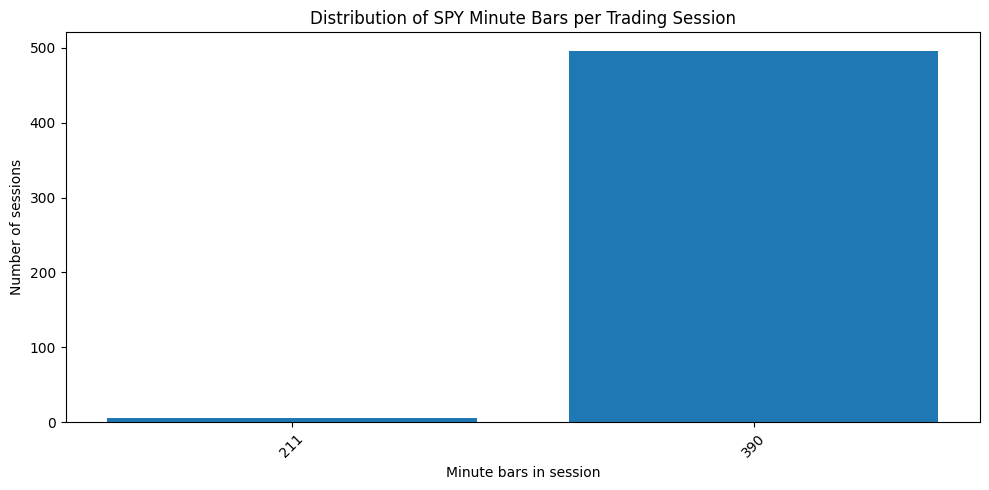

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\01_session_bar_count_distribution.png


In [8]:
bar_count_frequency = (
    session_audit["rows"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bar_count_frequency.index.astype(str), bar_count_frequency.values)
ax.set_title("Distribution of SPY Minute Bars per Trading Session")
ax.set_xlabel("Minute bars in session")
ax.set_ylabel("Number of sessions")
ax.tick_params(axis="x", rotation=45)
path = save_figure(fig, "01_session_bar_count_distribution.png")
plt.show()
print("Saved:", path)

### Graphs: SPX and VIX match staleness

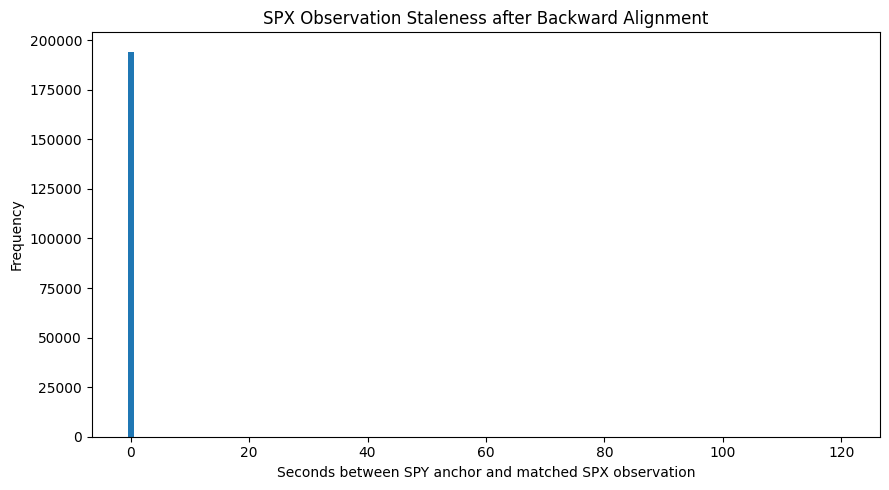

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\02_spx_alignment_staleness.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    aligned["spx_staleness_seconds"].dropna(),
    bins=np.arange(-0.5, 121.5, 1),
)
ax.set_title("SPX Observation Staleness after Backward Alignment")
ax.set_xlabel("Seconds between SPY anchor and matched SPX observation")
ax.set_ylabel("Frequency")
path = save_figure(fig, "02_spx_alignment_staleness.png")
plt.show()
print("Saved:", path)

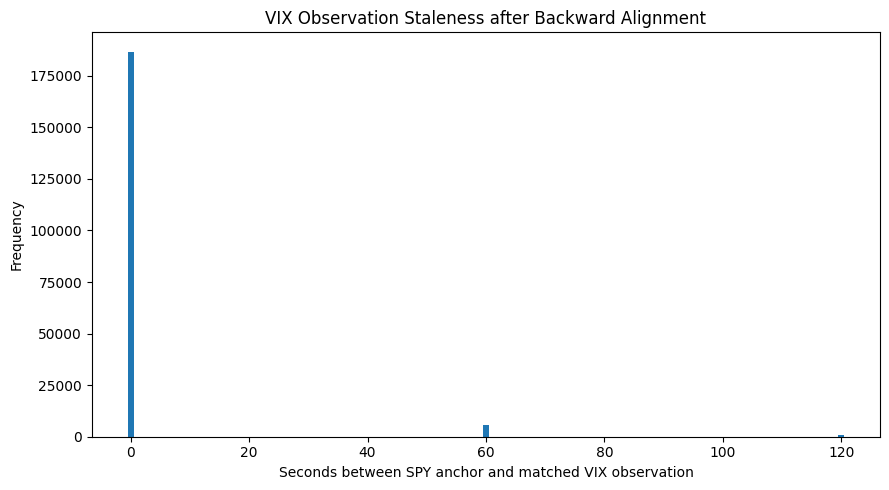

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\03_vix_alignment_staleness.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    aligned["vix_staleness_seconds"].dropna(),
    bins=np.arange(-0.5, 121.5, 1),
)
ax.set_title("VIX Observation Staleness after Backward Alignment")
ax.set_xlabel("Seconds between SPY anchor and matched VIX observation")
ax.set_ylabel("Frequency")
path = save_figure(fig, "03_vix_alignment_staleness.png")
plt.show()
print("Saved:", path)

### Graph: missing aligned values by session

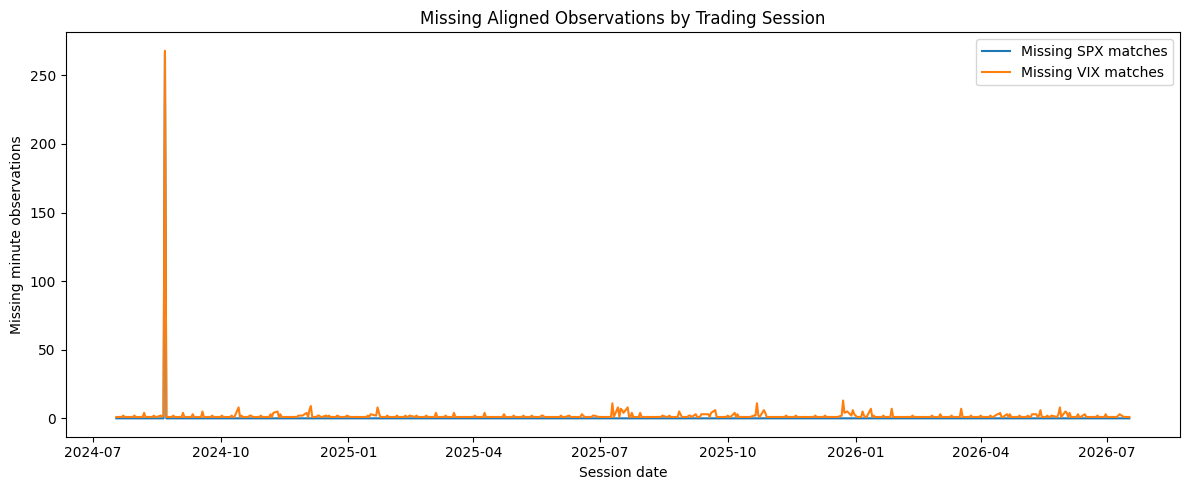

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\04_missing_matches_by_session.png


In [11]:
audit_dates = pd.to_datetime(session_audit["session_date"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(audit_dates, session_audit["missing_spx"], label="Missing SPX matches")
ax.plot(audit_dates, session_audit["missing_vix"], label="Missing VIX matches")
ax.set_title("Missing Aligned Observations by Trading Session")
ax.set_xlabel("Session date")
ax.set_ylabel("Missing minute observations")
ax.legend()
path = save_figure(fig, "04_missing_matches_by_session.png")
plt.show()
print("Saved:", path)

## 6. Save the aligned dataset and audit table

The Parquet files are portable research artifacts. The DuckDB tables allow subsequent notebooks to query the data directly.

In [12]:
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
AUDIT_PATH = DERIVED_ROOT / "underlying_session_audit.parquet"

aligned.to_parquet(ALIGNED_PATH, index=False)
session_audit.to_parquet(AUDIT_PATH, index=False)

con.register("aligned_dataframe", aligned)
con.execute(
    """
    CREATE OR REPLACE TABLE aligned_underlyings_1min AS
    SELECT * FROM aligned_dataframe
    """
)
con.unregister("aligned_dataframe")

con.register("session_audit_dataframe", session_audit)
con.execute(
    """
    CREATE OR REPLACE TABLE underlying_session_audit AS
    SELECT * FROM session_audit_dataframe
    """
)
con.unregister("session_audit_dataframe")

print("Saved aligned data:", ALIGNED_PATH)
print("Saved audit data:", AUDIT_PATH)

display(
    con.execute(
        """
        SELECT
            MIN(session_date) AS first_date,
            MAX(session_date) AS last_date,
            COUNT(*) AS minute_rows,
            COUNT(DISTINCT session_date) AS sessions
        FROM aligned_underlyings_1min
        """
    ).df()
)

Saved aligned data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\aligned_underlyings_1min.parquet
Saved audit data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\underlying_session_audit.parquet


,first_date,last_date,minute_rows,sessions
0,2024-07-18,2026-07-17,194495,501


## 7. Construct a daily look-ahead-safe modelling dataset

The feature window ends with the 14:59 ET bar. Sessions without both a 14:59 anchor and a 15:59 anchor are excluded from the daily target dataset.

`NEUTRAL_THRESHOLD` controls the target classes:

- `0.0` gives Up/Down and uses Flat only for an exact zero return;
- a positive value, such as `0.001`, creates a neutral band of ±0.10%.

Keep this setting consistent with the target definition used in the dissertation.

In [13]:
NEUTRAL_THRESHOLD = 0.0


def last_value_at_or_before(
    frame: pd.DataFrame,
    value_column: str,
    target_timestamp: pd.Timestamp,
):
    values = frame.loc[
        frame["timestamp_utc"].le(target_timestamp),
        ["timestamp_utc", value_column],
    ].dropna(subset=[value_column])

    if values.empty:
        return np.nan

    return values.iloc[-1][value_column]


def return_over_minutes(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    minutes: int,
):
    end_value = last_value_at_or_before(frame, value_column, end_timestamp)
    start_value = last_value_at_or_before(
        frame,
        value_column,
        end_timestamp - pd.Timedelta(minutes=minutes),
    )

    if pd.isna(end_value) or pd.isna(start_value) or start_value == 0:
        return np.nan

    return end_value / start_value - 1


def realized_volatility(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    minutes: int,
):
    start_timestamp = end_timestamp - pd.Timedelta(minutes=minutes)

    values = (
        frame.loc[
            frame["timestamp_utc"].between(start_timestamp, end_timestamp),
            ["timestamp_utc", value_column],
        ]
        .dropna(subset=[value_column])
        .drop_duplicates("timestamp_utc")
        .sort_values("timestamp_utc")
    )

    if len(values) < 3:
        return np.nan

    log_returns = np.log(values[value_column]).diff().dropna()
    return float(np.sqrt(np.square(log_returns).sum()))


def prior_window_return(
    frame: pd.DataFrame,
    value_column: str,
    end_timestamp: pd.Timestamp,
    recent_minutes: int,
):
    recent_start = end_timestamp - pd.Timedelta(minutes=recent_minutes)
    prior_start = end_timestamp - pd.Timedelta(minutes=2 * recent_minutes)

    recent_start_value = last_value_at_or_before(
        frame, value_column, recent_start
    )
    prior_start_value = last_value_at_or_before(
        frame, value_column, prior_start
    )

    if (
        pd.isna(recent_start_value)
        or pd.isna(prior_start_value)
        or prior_start_value == 0
    ):
        return np.nan

    return recent_start_value / prior_start_value - 1


def create_daily_record(session_date: str, group: pd.DataFrame):
    group = group.sort_values("timestamp_utc").copy()

    feature_window = group[group["clock_minute"] < 15 * 60]
    close_window = group[group["clock_minute"] < 16 * 60]

    if feature_window.empty or close_window.empty:
        return None

    if feature_window["clock_minute"].max() < (14 * 60 + 59):
        return None

    if close_window["clock_minute"].max() < (15 * 60 + 59):
        return None

    end_timestamp = feature_window["timestamp_utc"].max()

    spx_features = feature_window.dropna(subset=["spx_close"])
    vix_features = feature_window.dropna(subset=["vix_close"])
    spy_features = feature_window.dropna(subset=["spy_close"])
    spx_close_window = close_window.dropna(subset=["spx_close"])

    if (
        spx_features.empty
        or vix_features.empty
        or spy_features.empty
        or spx_close_window.empty
    ):
        return None

    spx_at_1500 = float(spx_features.iloc[-1]["spx_close"])
    spx_at_close = float(spx_close_window.iloc[-1]["spx_close"])
    vix_at_1500 = float(vix_features.iloc[-1]["vix_close"])
    spy_at_1500 = float(spy_features.iloc[-1]["spy_close"])

    spx_open_values = spx_features["spx_open"].dropna()
    spy_open_values = spy_features["spy_open"].dropna()

    if spx_open_values.empty or spy_open_values.empty:
        return None

    spx_open = float(spx_open_values.iloc[0])
    spy_open = float(spy_open_values.iloc[0])

    spx_high = float(spx_features["spx_high"].max())
    spx_low = float(spx_features["spx_low"].min())
    intraday_range = spx_high - spx_low

    spy_volume = pd.to_numeric(
        feature_window["spy_volume"], errors="coerce"
    ).fillna(0)

    spy_vwap_values = pd.to_numeric(
        feature_window["spy_vwap"], errors="coerce"
    )

    valid_vwap = spy_vwap_values.notna() & spy_volume.gt(0)

    if valid_vwap.any():
        cumulative_spy_vwap = float(
            np.average(
                spy_vwap_values[valid_vwap],
                weights=spy_volume[valid_vwap],
            )
        )
    else:
        cumulative_spy_vwap = np.nan

    last_30 = feature_window[
        feature_window["timestamp_utc"].gt(
            end_timestamp - pd.Timedelta(minutes=30)
        )
    ]

    last_60 = feature_window[
        feature_window["timestamp_utc"].gt(
            end_timestamp - pd.Timedelta(minutes=60)
        )
    ]

    earlier_volume = feature_window[
        feature_window["timestamp_utc"].le(
            end_timestamp - pd.Timedelta(minutes=60)
        )
    ]["spy_volume"]

    expected_last_60_volume = (
        pd.to_numeric(earlier_volume, errors="coerce").mean() * 60
        if len(earlier_volume)
        else np.nan
    )

    last_60_volume = pd.to_numeric(
        last_60["spy_volume"], errors="coerce"
    ).sum()

    volume_acceleration = (
        last_60_volume / expected_last_60_volume - 1
        if pd.notna(expected_last_60_volume)
        and expected_last_60_volume > 0
        else np.nan
    )

    previous_close = spx_features["spx_close"].shift(1)
    true_range = pd.concat(
        [
            spx_features["spx_high"] - spx_features["spx_low"],
            (spx_features["spx_high"] - previous_close).abs(),
            (spx_features["spx_low"] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)

    ret_last_60m = return_over_minutes(
        feature_window, "spx_close", end_timestamp, 60
    )
    ret_prior_60m = prior_window_return(
        feature_window, "spx_close", end_timestamp, 60
    )

    final_hour_return = (
        spx_at_close / spx_at_1500 - 1
        if spx_at_1500 != 0
        else np.nan
    )

    if final_hour_return > NEUTRAL_THRESHOLD:
        target_class = "Up"
    elif final_hour_return < -NEUTRAL_THRESHOLD:
        target_class = "Down"
    else:
        target_class = "Flat"

    return {
        "session_date": session_date,
        "feature_cutoff_timestamp_utc": end_timestamp,
        "spx_at_1500": spx_at_1500,
        "spx_at_close": spx_at_close,
        "vix_level_1500": vix_at_1500,
        "spy_at_1500": spy_at_1500,
        "final_hour_return": final_hour_return,
        "final_hour_direction": target_class,
        "ret_open_to_1500": spx_at_1500 / spx_open - 1,
        "ret_last_15m": return_over_minutes(
            feature_window, "spx_close", end_timestamp, 15
        ),
        "ret_last_30m": return_over_minutes(
            feature_window, "spx_close", end_timestamp, 30
        ),
        "ret_last_60m": ret_last_60m,
        "vix_ret_last_15m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 15
        ),
        "vix_ret_last_30m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 30
        ),
        "vix_ret_last_60m": return_over_minutes(
            feature_window, "vix_close", end_timestamp, 60
        ),
        "realized_vol_30m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 30
        ),
        "realized_vol_60m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 60
        ),
        "realized_vol_120m": realized_volatility(
            feature_window, "spx_close", end_timestamp, 120
        ),
        "rv_open_to_1500": realized_volatility(
            feature_window,
            "spx_close",
            end_timestamp,
            int(
                (
                    end_timestamp
                    - feature_window["timestamp_utc"].min()
                ).total_seconds()
                // 60
            ),
        ),
        "spy_ret_open_to_1500": spy_at_1500 / spy_open - 1,
        "spy_volume_last_30m": pd.to_numeric(
            last_30["spy_volume"], errors="coerce"
        ).sum(),
        "spy_volume_last_60m": last_60_volume,
        "spy_cum_volume_to_1500": spy_volume.sum(),
        "spy_volume_accel_60m_vs_avg": volume_acceleration,
        "spy_dist_from_vwap_pct": (
            spy_at_1500 / cumulative_spy_vwap - 1
            if pd.notna(cumulative_spy_vwap)
            and cumulative_spy_vwap != 0
            else np.nan
        ),
        "position_in_day_range": (
            (spx_at_1500 - spx_low) / intraday_range
            if intraday_range > 0
            else np.nan
        ),
        "dist_from_day_high_pct": spx_at_1500 / spx_high - 1,
        "dist_from_day_low_pct": spx_at_1500 / spx_low - 1,
        "dist_from_open_pct": spx_at_1500 / spx_open - 1,
        "momentum_accel_60m_vs_prior": (
            ret_last_60m - ret_prior_60m
            if pd.notna(ret_last_60m)
            and pd.notna(ret_prior_60m)
            else np.nan
        ),
        "atr_open_to_1500": float(true_range.mean()),
        "observations_before_1500": len(feature_window),
        "missing_spx_before_1500": int(
            feature_window["spx_close"].isna().sum()
        ),
        "missing_vix_before_1500": int(
            feature_window["vix_close"].isna().sum()
        ),
    }


daily_records = []

for session_date, group in aligned.groupby("session_date"):
    record = create_daily_record(session_date, group)
    if record is not None:
        daily_records.append(record)

daily_model = pd.DataFrame(daily_records)
daily_model["session_date"] = pd.to_datetime(daily_model["session_date"])
daily_model["day_of_week"] = daily_model["session_date"].dt.day_name()
daily_model["month"] = daily_model["session_date"].dt.to_period("M").astype(str)
daily_model = daily_model.sort_values("session_date").reset_index(drop=True)

if daily_model.empty:
    raise RuntimeError(
        "No valid daily modelling rows were created. "
        "Inspect the session audit and ticker data."
    )

display(daily_model.head())
print("Daily modelling sessions:", len(daily_model))
print(
    "Date range:",
    daily_model["session_date"].min().date(),
    "to",
    daily_model["session_date"].max().date(),
)

,session_date,feature_cutoff_timestamp_utc,spx_at_1500,spx_at_close,vix_level_1500,spy_at_1500,final_hour_return,final_hour_direction,ret_open_to_1500,ret_last_15m,ret_last_30m,ret_last_60m,vix_ret_last_15m,vix_ret_last_30m,vix_ret_last_60m,realized_vol_30m,realized_vol_60m,realized_vol_120m,rv_open_to_1500,spy_ret_open_to_1500,spy_volume_last_30m,spy_volume_last_60m,spy_cum_volume_to_1500,spy_volume_accel_60m_vs_avg,spy_dist_from_vwap_pct,position_in_day_range,dist_from_day_high_pct,dist_from_day_low_pct,dist_from_open_pct,momentum_accel_60m_vs_prior,atr_open_to_1500,observations_before_1500,missing_spx_before_1500,missing_vix_before_1500,day_of_week,month
0,2024-07-18,2024-07-18 18:59:00+00:00,"5,542.030000","5,545.250000",15.990000,552.380000,0.000581,Up,-0.011862,0.000551,-0.000388,-0.002195,-0.004978,0.002508,0.006927,0.001875,0.002449,0.003331,0.006326,-0.010976,"3,575,960.000000","5,901,091.000000","32,419,444.000000",0.001379,-0.005213,0.115233,-0.012829,0.001695,-0.011862,-0.000943,2.477364,330,0,1,Thursday,2024-07
1,2024-07-19,2024-07-19 18:59:00+00:00,"5,508.650000","5,505.730000",16.710000,549.120000,-0.000530,Down,-0.006263,0.001742,0.000810,-0.000566,-0.019366,-0.011827,-0.007130,0.000960,0.001691,0.003028,0.006094,-0.005974,"2,941,827.000000","4,990,322.000000","38,431,776.000000",-0.328485,-0.003350,0.192028,-0.008790,0.002112,-0.006263,-0.000588,2.282939,330,0,1,Friday,2024-07
2,2024-07-22,2024-07-22 18:59:00+00:00,"5,566.430000","5,563.960000",14.910000,554.815000,-0.000444,Down,0.003948,-0.000402,0.000377,0.000626,0.002690,0.000000,-0.000670,0.000772,0.001464,0.002192,0.005771,0.003282,"1,878,697.000000","3,489,001.000000","25,668,548.000000",-0.292118,0.002914,0.904889,-0.000706,0.006762,0.003948,-0.001188,2.033364,330,0,1,Monday,2024-07
3,2024-07-23,2024-07-23 18:59:00+00:00,"5,568.740000","5,556.270000",14.410000,555.090100,-0.002239,Down,0.000618,0.000169,0.000456,-0.000244,-0.000693,-0.008259,-0.009622,0.000815,0.001450,0.002166,0.004584,0.000992,"991,175.000000","2,310,726.000000","19,488,929.000000",-0.394682,-0.000409,0.359815,-0.002972,0.001678,0.000618,-0.001346,1.734939,330,0,1,Tuesday,2024-07
4,2024-07-24,2024-07-24 18:59:00+00:00,"5,441.610000","5,428.380000",17.860000,542.480000,-0.002431,Down,-0.011666,-0.000270,-0.001604,-0.002636,0.005631,0.021739,0.033565,0.001701,0.002059,0.002687,0.004524,-0.011624,"4,689,642.000000","7,516,796.000000","36,693,306.000000",0.159343,-0.006470,0.084482,-0.012061,0.001128,-0.011666,-0.002694,1.834515,330,0,1,Wednesday,2024-07


Daily modelling sessions: 496
Date range: 2024-07-18 to 2026-07-17


## 8. Save the daily modelling dataset

This table is the appropriate starting point for feature EDA, feature selection and time-series model validation.

In [14]:
DAILY_MODEL_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"

daily_model.to_parquet(DAILY_MODEL_PATH, index=False)

con.register("daily_model_dataframe", daily_model)
con.execute(
    """
    CREATE OR REPLACE TABLE daily_underlying_model_dataset AS
    SELECT * FROM daily_model_dataframe
    """
)
con.unregister("daily_model_dataframe")

print("Saved daily modelling data:", DAILY_MODEL_PATH)

display(
    con.execute(
        """
        SELECT
            MIN(session_date) AS first_date,
            MAX(session_date) AS last_date,
            COUNT(*) AS sessions
        FROM daily_underlying_model_dataset
        """
    ).df()
)

Saved daily modelling data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset.parquet


,first_date,last_date,sessions
0,2024-07-18,2026-07-17,496


# Exploratory Data Analysis

The following section examines coverage, missingness, distributions, relationships and time variation. Each figure is saved automatically as a high-resolution PNG.

## 9. Descriptive statistics and missingness

In [15]:
eda_columns = [
    "final_hour_return",
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_ret_open_to_1500",
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "momentum_accel_60m_vs_prior",
    "atr_open_to_1500",
]

descriptive_statistics = daily_model[eda_columns].describe().T
descriptive_statistics["skewness"] = daily_model[eda_columns].skew()
descriptive_statistics["kurtosis"] = daily_model[eda_columns].kurtosis()

display(descriptive_statistics)

missingness = pd.DataFrame(
    {
        "missing_values": daily_model[eda_columns].isna().sum(),
        "missing_pct": daily_model[eda_columns].isna().mean() * 100,
    }
).sort_values("missing_pct", ascending=False)

display(missingness)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
final_hour_return,496.000000,-0.000023,0.002940,-0.016814,-0.001273,-0.000029,0.001288,0.023114,0.609867,11.221998
ret_open_to_1500,496.000000,0.000168,0.007613,-0.037053,-0.003446,0.000481,0.004637,0.073142,1.126522,18.197619
ret_last_15m,496.000000,-0.000133,0.001261,-0.007059,-0.000456,-0.000037,0.000411,0.005142,-1.270311,7.090442
ret_last_30m,496.000000,-0.000086,0.001746,-0.013975,-0.000638,0.000046,0.000750,0.006504,-1.161169,9.812802
ret_last_60m,496.000000,-0.000099,0.002633,-0.015158,-0.001046,0.000057,0.001068,0.013302,-0.484624,6.471317
vix_level_1500,496.000000,18.758286,4.561458,13.010000,15.990000,17.450000,19.922500,50.170000,2.777736,11.829738
vix_ret_last_15m,496.000000,-0.000775,0.011785,-0.050121,-0.006302,-0.001292,0.002441,0.096736,1.906449,13.999969
vix_ret_last_30m,496.000000,-0.001472,0.015769,-0.057519,-0.008820,-0.002747,0.004845,0.116616,1.288073,8.281268
vix_ret_last_60m,496.000000,-0.002342,0.024794,-0.092834,-0.011885,-0.003852,0.006050,0.218997,1.742065,14.546646
realized_vol_30m,495.000000,0.001410,0.001106,0.000286,0.000729,0.001068,0.001754,0.009994,3.341358,17.610705


,missing_values,missing_pct
realized_vol_30m,1,0.201613
realized_vol_60m,1,0.201613
realized_vol_120m,1,0.201613
final_hour_return,0,0.000000
spy_volume_last_30m,0,0.000000
momentum_accel_60m_vs_prior,0,0.000000
dist_from_day_low_pct,0,0.000000
dist_from_day_high_pct,0,0.000000
position_in_day_range,0,0.000000
spy_dist_from_vwap_pct,0,0.000000


## 10. Target distribution and class balance

In [16]:
target_summary = daily_model["final_hour_return"].describe().to_frame(
    "final_hour_return"
)
display(target_summary)

class_distribution = (
    daily_model["final_hour_direction"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="sessions")
)

class_distribution["percentage"] = (
    class_distribution["sessions"] / len(daily_model) * 100
)

display(class_distribution)

,final_hour_return
count,496.000000
mean,-0.000023
std,0.002940
min,-0.016814
25%,-0.001273
50%,-0.000029
75%,0.001288
max,0.023114


,class,sessions,percentage
0,Down,251,50.604839
1,Up,244,49.193548
2,Flat,1,0.201613


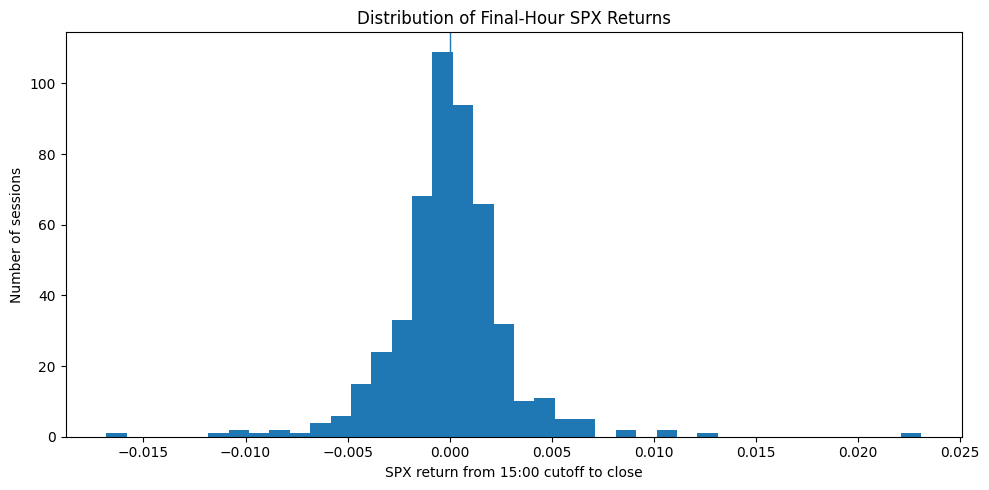

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\05_final_hour_return_distribution.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(daily_model["final_hour_return"].dropna(), bins=40)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of Final-Hour SPX Returns")
ax.set_xlabel("SPX return from 15:00 cutoff to close")
ax.set_ylabel("Number of sessions")
path = save_figure(fig, "05_final_hour_return_distribution.png")
plt.show()
print("Saved:", path)

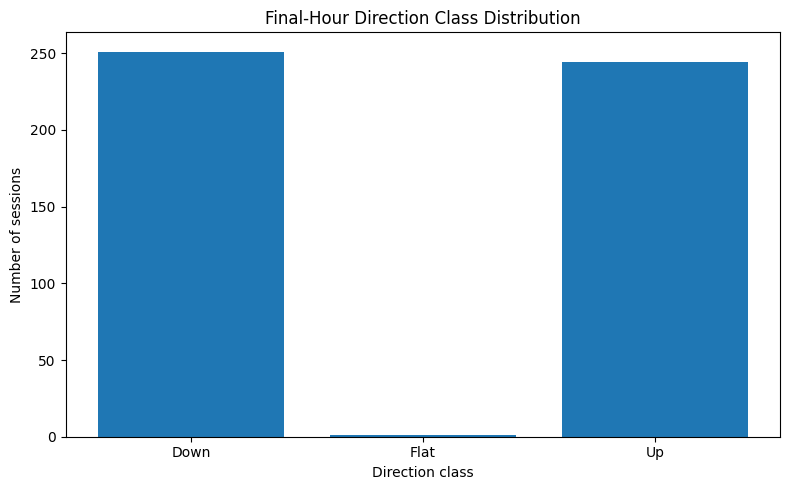

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\06_direction_class_distribution.png


In [18]:
class_counts = (
    daily_model["final_hour_direction"]
    .value_counts()
    .reindex(["Down", "Flat", "Up"])
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values)
ax.set_title("Final-Hour Direction Class Distribution")
ax.set_xlabel("Direction class")
ax.set_ylabel("Number of sessions")
path = save_figure(fig, "06_direction_class_distribution.png")
plt.show()
print("Saved:", path)

## 11. Market levels and target behaviour through time

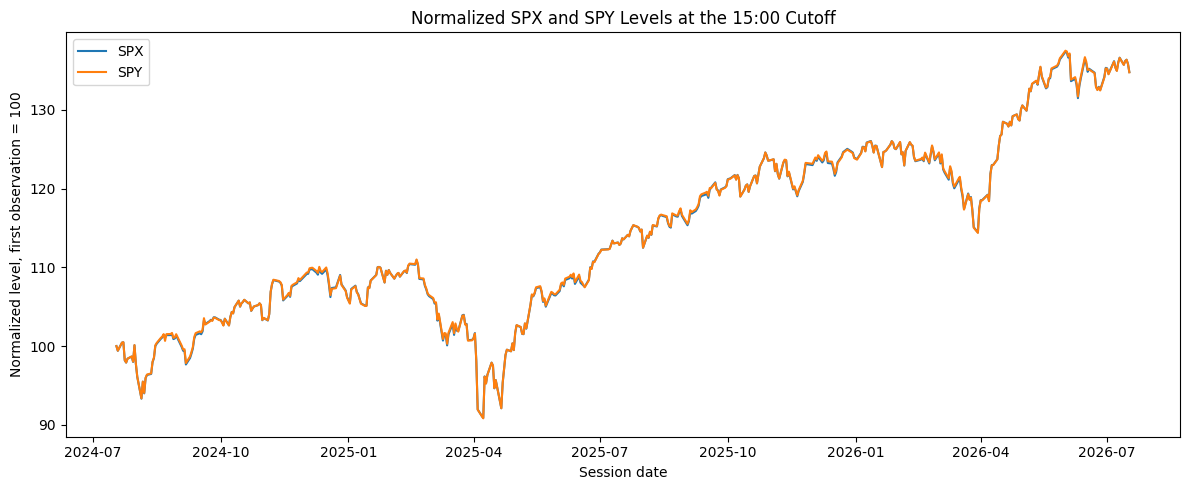

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\07_normalized_spx_spy_levels.png


In [19]:
levels = daily_model[
    ["session_date", "spx_at_1500", "spy_at_1500"]
].dropna().copy()

levels["SPX normalized"] = (
    levels["spx_at_1500"] / levels["spx_at_1500"].iloc[0] * 100
)
levels["SPY normalized"] = (
    levels["spy_at_1500"] / levels["spy_at_1500"].iloc[0] * 100
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(levels["session_date"], levels["SPX normalized"], label="SPX")
ax.plot(levels["session_date"], levels["SPY normalized"], label="SPY")
ax.set_title("Normalized SPX and SPY Levels at the 15:00 Cutoff")
ax.set_xlabel("Session date")
ax.set_ylabel("Normalized level, first observation = 100")
ax.legend()
path = save_figure(fig, "07_normalized_spx_spy_levels.png")
plt.show()
print("Saved:", path)

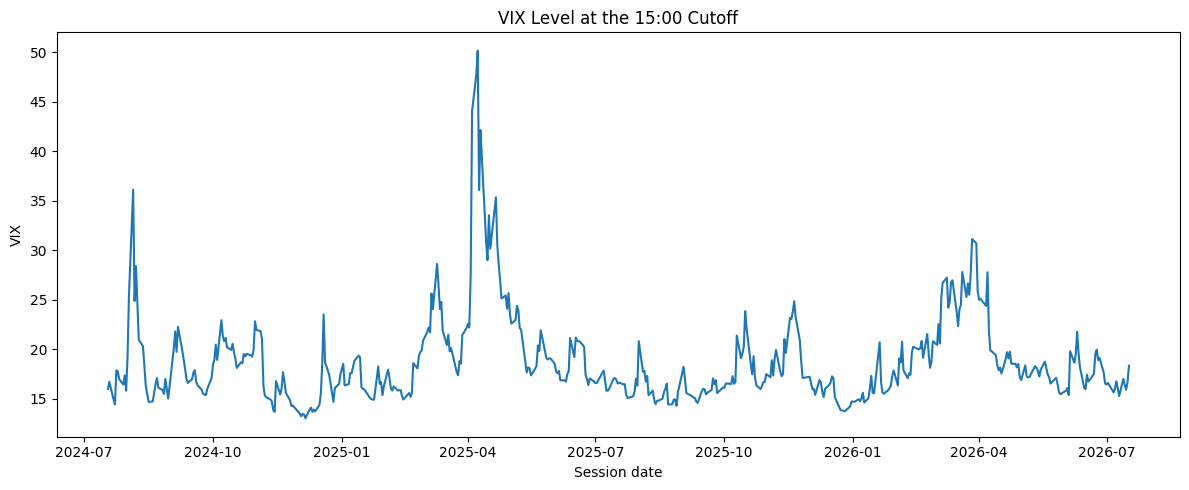

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\08_vix_level_over_time.png


In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_model["session_date"], daily_model["vix_level_1500"])
ax.set_title("VIX Level at the 15:00 Cutoff")
ax.set_xlabel("Session date")
ax.set_ylabel("VIX")
path = save_figure(fig, "08_vix_level_over_time.png")
plt.show()
print("Saved:", path)

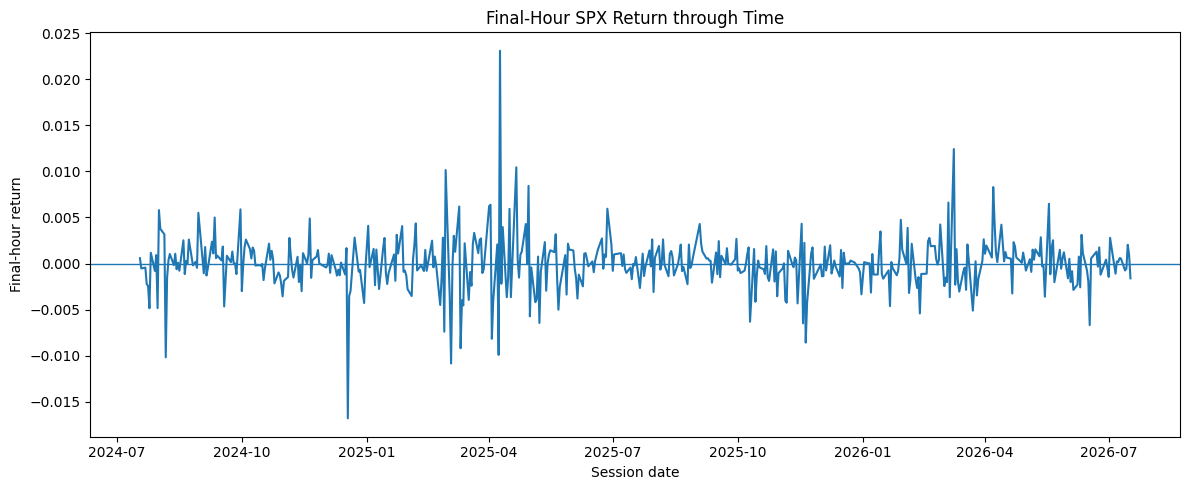

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\09_final_hour_return_over_time.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    daily_model["session_date"],
    daily_model["final_hour_return"],
)
ax.axhline(0, linewidth=1)
ax.set_title("Final-Hour SPX Return through Time")
ax.set_xlabel("Session date")
ax.set_ylabel("Final-hour return")
path = save_figure(fig, "09_final_hour_return_over_time.png")
plt.show()
print("Saved:", path)

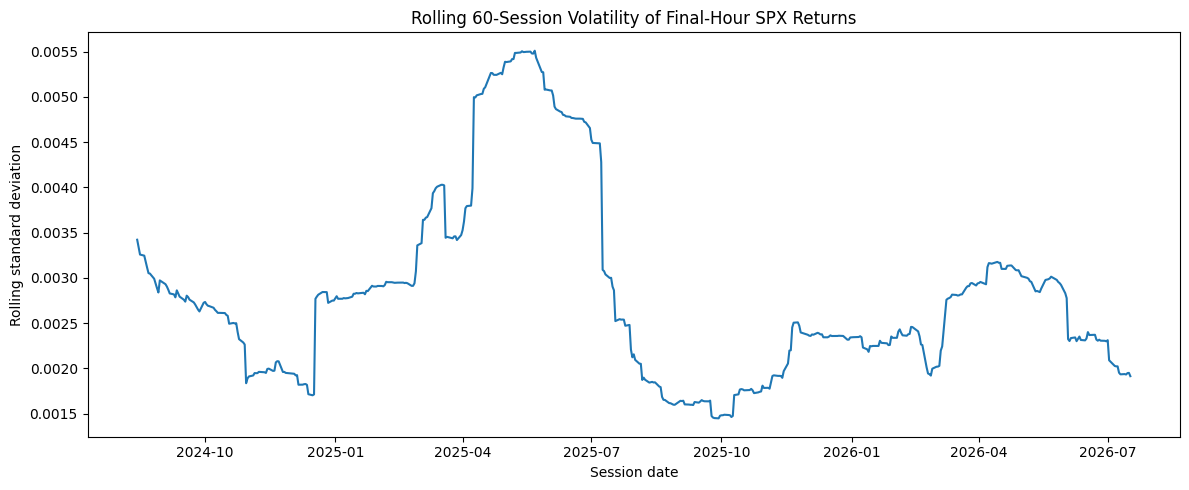

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\10_rolling_final_hour_volatility.png


In [22]:
rolling_window = 60

rolling_target_volatility = (
    daily_model["final_hour_return"]
    .rolling(rolling_window, min_periods=20)
    .std()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    daily_model["session_date"],
    rolling_target_volatility,
)
ax.set_title(
    f"Rolling {rolling_window}-Session Volatility of Final-Hour SPX Returns"
)
ax.set_xlabel("Session date")
ax.set_ylabel("Rolling standard deviation")
path = save_figure(fig, "10_rolling_final_hour_volatility.png")
plt.show()
print("Saved:", path)

## 12. Weekday analysis

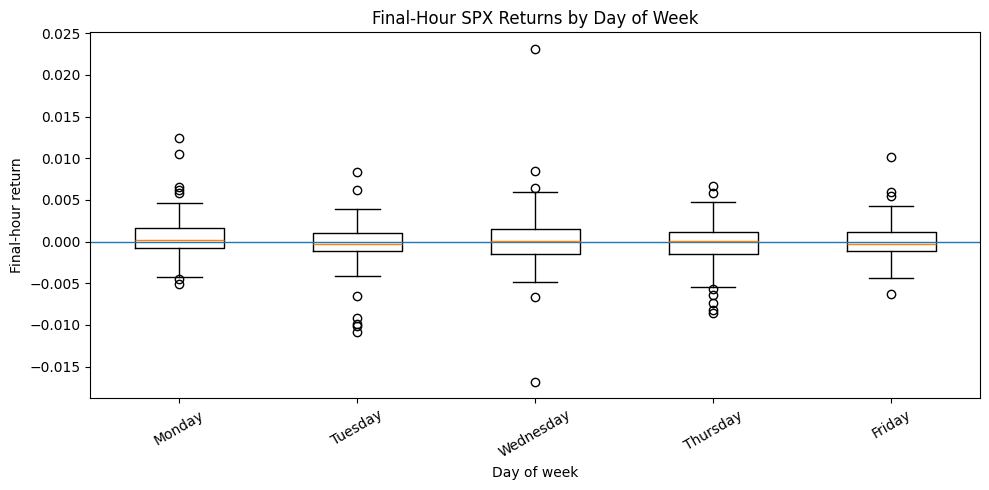

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\11_final_hour_return_by_weekday.png


,count,mean,median,std
day_of_week,,,,
Monday,96,0.000505,0.000189,0.002777
Tuesday,103,-0.000368,-0.000308,0.002814
Wednesday,101,0.000203,0.000037,0.003765
Thursday,98,-0.000377,0.000126,0.002799
Friday,98,-0.000058,-0.000306,0.002278


In [23]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
]

weekday_values = [
    daily_model.loc[
        daily_model["day_of_week"].eq(day),
        "final_hour_return",
    ].dropna()
    for day in weekday_order
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(weekday_values, labels=weekday_order, showfliers=True)
ax.axhline(0, linewidth=1)
ax.set_title("Final-Hour SPX Returns by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Final-hour return")
ax.tick_params(axis="x", rotation=30)
path = save_figure(fig, "11_final_hour_return_by_weekday.png")
plt.show()
print("Saved:", path)

display(
    daily_model.groupby("day_of_week")["final_hour_return"]
    .agg(["count", "mean", "median", "std"])
    .reindex(weekday_order)
)

## 13. Relationships with volatility and earlier momentum

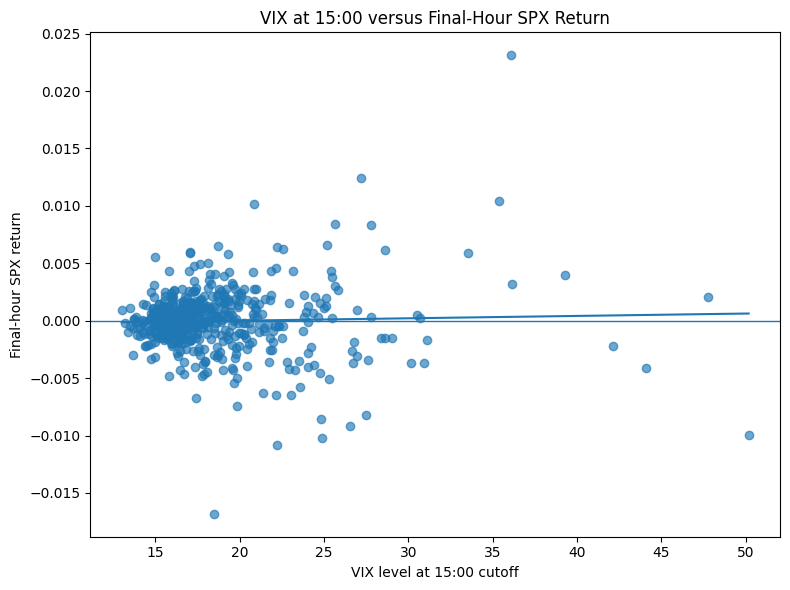

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\12_vix_vs_final_hour_return.png


In [24]:
scatter_data = daily_model[
    ["vix_level_1500", "final_hour_return"]
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    scatter_data["vix_level_1500"],
    scatter_data["final_hour_return"],
    alpha=0.65,
)

if len(scatter_data) >= 2:
    slope, intercept = np.polyfit(
        scatter_data["vix_level_1500"],
        scatter_data["final_hour_return"],
        1,
    )
    x_line = np.linspace(
        scatter_data["vix_level_1500"].min(),
        scatter_data["vix_level_1500"].max(),
        100,
    )
    ax.plot(x_line, slope * x_line + intercept)

ax.axhline(0, linewidth=1)
ax.set_title("VIX at 15:00 versus Final-Hour SPX Return")
ax.set_xlabel("VIX level at 15:00 cutoff")
ax.set_ylabel("Final-hour SPX return")
path = save_figure(fig, "12_vix_vs_final_hour_return.png")
plt.show()
print("Saved:", path)

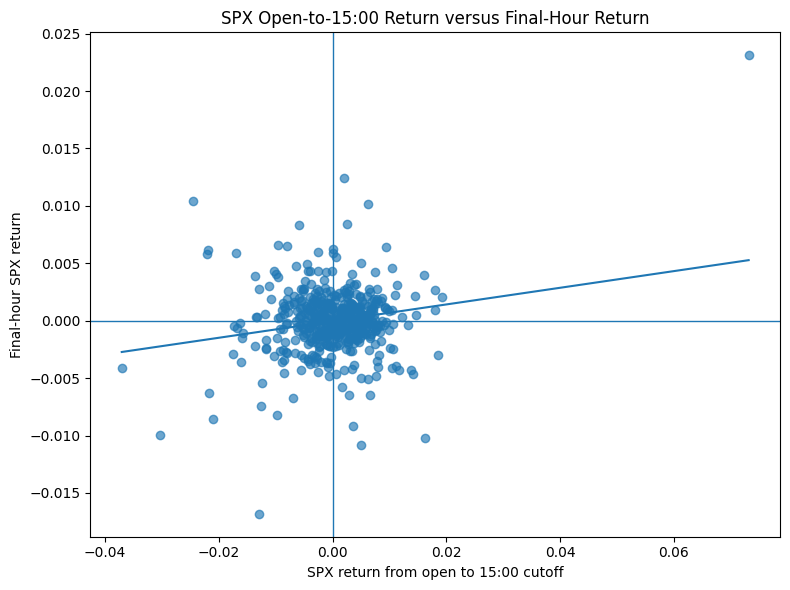

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\13_open_to_1500_vs_final_hour_return.png


In [25]:
scatter_data = daily_model[
    ["ret_open_to_1500", "final_hour_return"]
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    scatter_data["ret_open_to_1500"],
    scatter_data["final_hour_return"],
    alpha=0.65,
)

if len(scatter_data) >= 2:
    slope, intercept = np.polyfit(
        scatter_data["ret_open_to_1500"],
        scatter_data["final_hour_return"],
        1,
    )
    x_line = np.linspace(
        scatter_data["ret_open_to_1500"].min(),
        scatter_data["ret_open_to_1500"].max(),
        100,
    )
    ax.plot(x_line, slope * x_line + intercept)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_title("SPX Open-to-15:00 Return versus Final-Hour Return")
ax.set_xlabel("SPX return from open to 15:00 cutoff")
ax.set_ylabel("Final-hour SPX return")
path = save_figure(fig, "13_open_to_1500_vs_final_hour_return.png")
plt.show()
print("Saved:", path)

## 14. Feature correlations

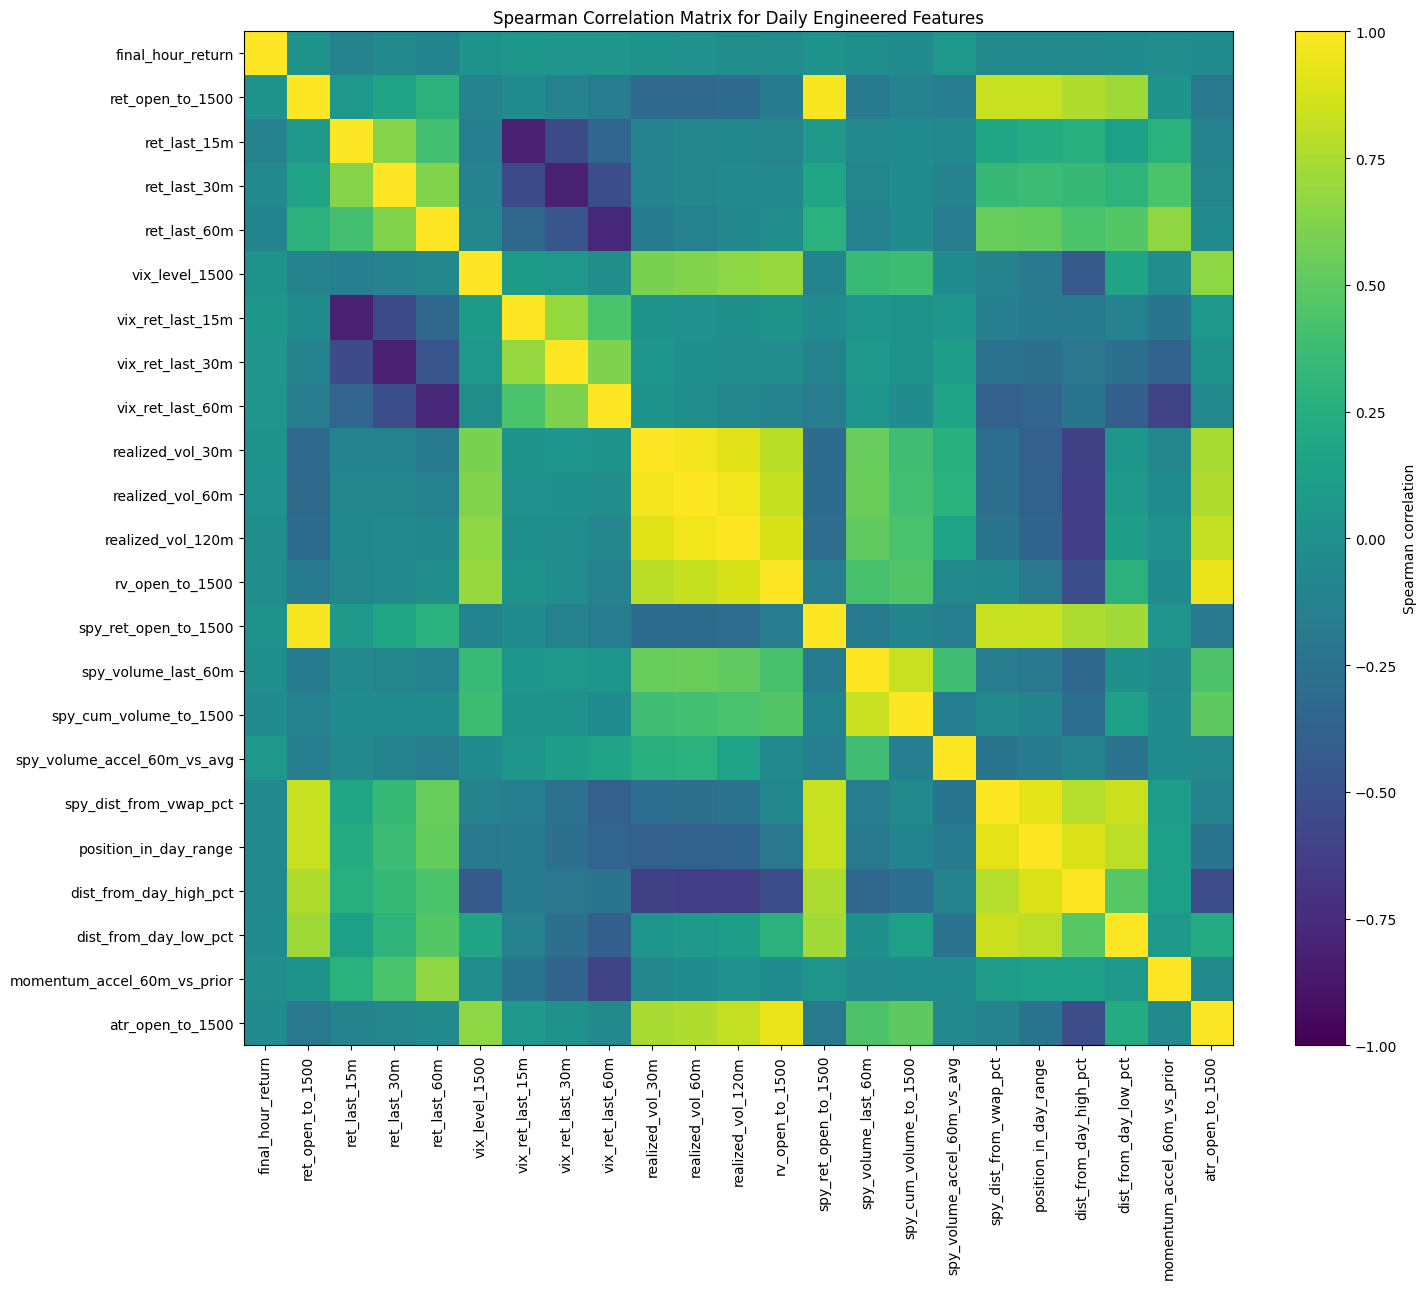

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\14_feature_correlation_matrix.png


In [26]:
correlation_columns = [
    "final_hour_return",
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_ret_open_to_1500",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "momentum_accel_60m_vs_prior",
    "atr_open_to_1500",
]

correlation_matrix = daily_model[correlation_columns].corr(
    method="spearman"
)

fig, ax = plt.subplots(figsize=(15, 13))
image = ax.imshow(
    correlation_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=90)
ax.set_yticklabels(correlation_columns)
ax.set_title("Spearman Correlation Matrix for Daily Engineered Features")
fig.colorbar(image, ax=ax, label="Spearman correlation")
path = save_figure(fig, "14_feature_correlation_matrix.png")
plt.show()
print("Saved:", path)

,spearman_correlation_with_final_hour_return
ret_last_15m,-0.105774
ret_last_60m,-0.098345
ret_last_30m,-0.054406
position_in_day_range,-0.048945
dist_from_day_high_pct,-0.048727
spy_dist_from_vwap_pct,-0.048531
dist_from_day_low_pct,-0.037526
atr_open_to_1500,-0.036270
spy_cum_volume_to_1500,-0.031280
rv_open_to_1500,-0.023161


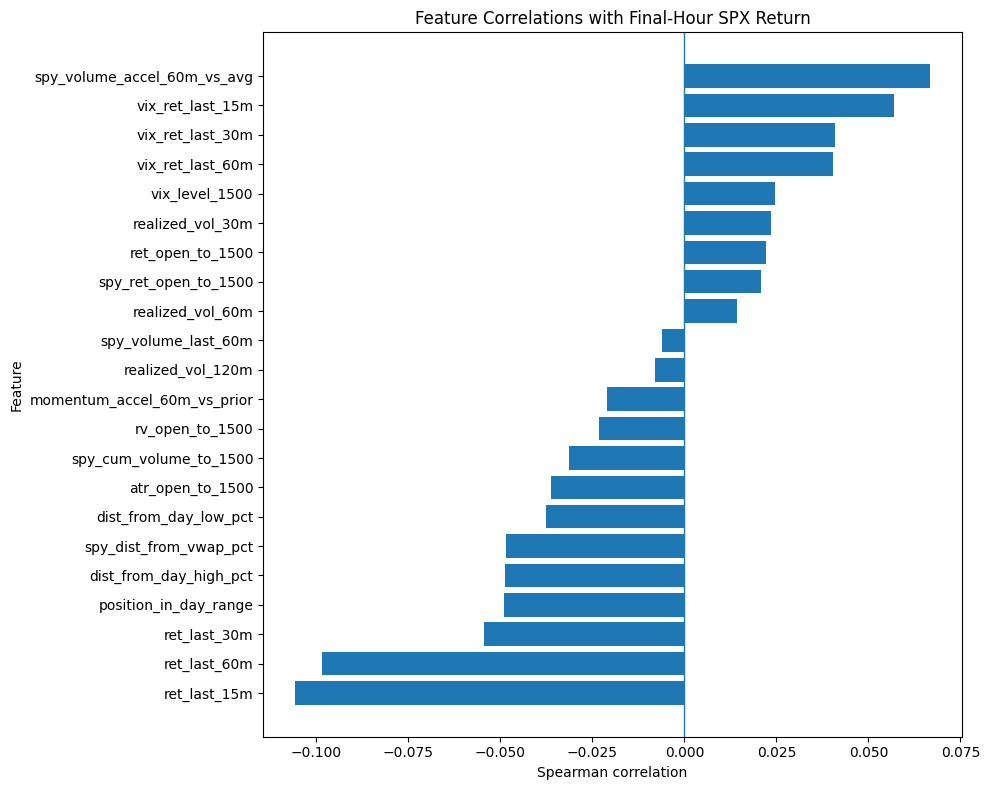

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\eda_figures\15_feature_target_correlations.png


In [27]:
target_correlations = (
    correlation_matrix["final_hour_return"]
    .drop("final_hour_return")
    .sort_values()
)

display(
    target_correlations.to_frame(
        "spearman_correlation_with_final_hour_return"
    )
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(target_correlations.index, target_correlations.values)
ax.axvline(0, linewidth=1)
ax.set_title("Feature Correlations with Final-Hour SPX Return")
ax.set_xlabel("Spearman correlation")
ax.set_ylabel("Feature")
path = save_figure(fig, "15_feature_target_correlations.png")
plt.show()
print("Saved:", path)

## 15. EDA output summary and next decision

Before modelling:

1. inspect every row in `problem_sessions`;
2. verify that the daily dataset excludes early-close and partial sessions;
3. decide whether the target needs a neutral threshold;
4. compare these reconstructed features with the original project definitions;
5. use chronological train/validation/test splits rather than random splits.

After these checks, proceed to the controlled SPX option-history notebook.

In [28]:
output_summary = pd.DataFrame(
    {
        "artifact": [
            "Aligned one-minute dataset",
            "Session audit",
            "Daily modelling dataset",
            "EDA figure directory",
        ],
        "location": [
            str(ALIGNED_PATH),
            str(AUDIT_PATH),
            str(DAILY_MODEL_PATH),
            str(FIGURE_ROOT),
        ],
        "rows_or_files": [
            len(aligned),
            len(session_audit),
            len(daily_model),
            len(list(FIGURE_ROOT.glob("*.png"))),
        ],
    }
)

display(output_summary)

print("Notebook completed successfully.")
print("No Massive API calls were made.")
print("All feature calculations used observations strictly before 15:00 ET.")

,artifact,location,rows_or_files
0,Aligned one-minute dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...,194495
1,Session audit,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...,501
2,Daily modelling dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...,496
3,EDA figure directory,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...,15


Notebook completed successfully.
No Massive API calls were made.
All feature calculations used observations strictly before 15:00 ET.
